# Montreal City Walkthrough

This notebook builds a Montreal-focused demo from the local `urban-energy-data` sibling plus the managed Montreal 3D building dataset on `Z:`.

It shows:
- what data pieces are available
- how to assemble a Montreal city object
- a small-sample workflow for visualization and analytics

The analytics demo uses roughly 5% of FSAs and 5% of buildings so it stays usable in a notebook.

In [1]:
from pathlib import Path
import subprocess
import sys
import warnings

from tqdm import TqdmWarning
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", message=r".*IProgress not found.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, message=r".*unary_union.*deprecated.*")
warnings.filterwarnings("ignore", category=UserWarning, message=r".*Geometry is in a geographic CRS.*")

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd().resolve()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from urban_energy_core.io import (
    combine_montreal_building_sources,
    load_all_da_census,
    load_all_fsa_census,
    load_city_da_geojsons,
    load_city_fsa_geojsons,
    load_city_weather_csvs,
    load_montreal_building_geometry,
    load_montreal_building_inventory,
    load_processed_electricity_wide,
)
from urban_energy_core.pipelines import build_cities_from_data
from urban_energy_core.plotting import plot_spatial_samples_with_basemap


In [2]:
DATA_ROOT = REPO_ROOT.parent / "urban-energy-data"
Z_3D_ROOT = Path(r"Z:\Public\Montreal 3D data")

ELEC_PATH = DATA_ROOT / "data" / "processed" / "electricity" / "elec_rebuilt_new_weather.parquet"
FSA_CENSUS_ROOT = DATA_ROOT / "data" / "raw" / "census" / "FSA scale"
DA_CENSUS_ROOT = DATA_ROOT / "data" / "raw" / "census" / "DA scale"
GEOMETRY_ROOT = DATA_ROOT / "data" / "raw" / "geometry"
WEATHER_ROOT = DATA_ROOT / "data" / "raw" / "weather"
BUILDINGS_ROOT = DATA_ROOT / "data" / "raw" / "buildings" / "montreal"
LOD1_PATH = BUILDINGS_ROOT / "LoD1.parquet"
EXT_BUILDING_GEO_PATH = Z_3D_ROOT / "Mtl_Buildings_Dec2022_KKv1.geojson"

availability_df = pd.DataFrame(
    {
        "input": [
            "shared_data_root",
            "fsa_electricity",
            "fsa_census",
            "da_census",
            "geometry",
            "weather",
            "montreal_building_inventory",
            "managed_montreal_3d_geometry",
        ],
        "available": [
            DATA_ROOT.exists(),
            ELEC_PATH.exists(),
            FSA_CENSUS_ROOT.exists(),
            DA_CENSUS_ROOT.exists(),
            GEOMETRY_ROOT.exists(),
            WEATHER_ROOT.exists(),
            LOD1_PATH.exists(),
            EXT_BUILDING_GEO_PATH.exists(),
        ],
    }
)
availability_df


,input,available
0,shared_data_root,True
1,fsa_electricity,True
2,fsa_census,True
3,da_census,True
4,geometry,True
5,weather,True
6,montreal_building_inventory,True
7,managed_montreal_3d_geometry,True


In [3]:
print("Dataset inspection is available via scripts/inspect_data_root.py when needed; notebook output keeps path details out of the committed demo.")


Dataset inspection is available via scripts/inspect_data_root.py when needed; notebook output keeps path details out of the committed demo.


## Load Montreal Inputs

In [4]:
elec_df = load_processed_electricity_wide(ELEC_PATH)

fsa_census_df = load_all_fsa_census(root_dir=FSA_CENSUS_ROOT, drop_key_col=False, show_progress=False)
if "GEO UID" in fsa_census_df.columns:
    fsa_census_df = fsa_census_df.set_index("GEO UID")
fsa_census_df.index = fsa_census_df.index.astype(str)

da_census_df = load_all_da_census(root_dir=DA_CENSUS_ROOT, drop_key_col=False, show_progress=False)
if "DAUID" in da_census_df.columns:
    da_census_df = da_census_df.set_index("DAUID")
da_census_df.index = da_census_df.index.astype(str)

fsa_geo = load_city_fsa_geojsons(geometry_dir=GEOMETRY_ROOT, show_progress=False)["montreal"]
da_geo = load_city_da_geojsons(geometry_dir=GEOMETRY_ROOT, show_progress=False)["montreal"]

fsa_geo_3857 = fsa_geo.to_crs(epsg=3857)
da_geo_3857 = da_geo.to_crs(epsg=3857)
montreal_boundary = fsa_geo_3857.union_all()
da_mask = da_geo_3857.geometry.centroid.within(montreal_boundary)
da_geo = da_geo.loc[da_mask.values].copy()

da_codes_montreal = pd.Index(da_geo["DAUID"].astype(str).unique())
da_census_df = da_census_df.loc[da_census_df.index.intersection(da_codes_montreal)].copy()
weather_df = load_city_weather_csvs(weather_dir=WEATHER_ROOT, show_progress=False)["montreal"]

building_inventory_df = load_montreal_building_inventory(LOD1_PATH)
building_geo_gdf = load_montreal_building_geometry(EXT_BUILDING_GEO_PATH)
if building_geo_gdf.crs != fsa_geo.crs:
    building_geo_gdf = building_geo_gdf.to_crs(fsa_geo.crs)

building_df = combine_montreal_building_sources(
    inventory_df=building_inventory_df,
    primary_geometry_gdf=building_geo_gdf,
)

summary_df = pd.DataFrame(
    {
        "dataset": [
            "FSA electricity",
            "FSA census",
            "DA census",
            "Montreal FSA geometry",
            "Montreal DA geometry",
            "Montreal weather",
            "Montreal building inventory+geometry",
        ],
        "rows": [
            len(elec_df),
            len(fsa_census_df),
            len(da_census_df),
            len(fsa_geo),
            len(da_geo),
            len(weather_df),
            len(building_df),
        ],
        "cols": [
            elec_df.shape[1],
            fsa_census_df.shape[1],
            da_census_df.shape[1],
            len(fsa_geo.columns),
            len(da_geo.columns),
            weather_df.shape[1],
            building_df.shape[1],
        ],
    }
)
summary_df


,dataset,rows,cols
0,FSA electricity,140256,133
1,FSA census,1646,1122
2,DA census,3179,140
3,Montreal FSA geometry,94,4
4,Montreal DA geometry,3179,5
5,Montreal weather,52608,2
6,Montreal building inventory+geometry,322817,140


## Sample About 5% for the Interactive Demo

In [5]:
SAMPLE_FRACTION = 0.05
RANDOM_SEED = 42

mtl_fsa_codes = sorted([code for code in fsa_geo["FSA"].astype(str).unique() if code in elec_df.columns])
n_fsa_sample = max(5, round(len(mtl_fsa_codes) * SAMPLE_FRACTION))
sampled_fsa_codes = sorted(pd.Series(mtl_fsa_codes).sample(n=n_fsa_sample, random_state=RANDOM_SEED).tolist())

sampled_building_df = building_df.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_SEED).reset_index(drop=True)
sampled_da_geo = da_geo.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_SEED).reset_index(drop=True)

sampled_fsa_geo = fsa_geo[fsa_geo["FSA"].astype(str).isin(sampled_fsa_codes)].copy()
sampled_fsa_census_df = fsa_census_df.loc[fsa_census_df.index.intersection(sampled_fsa_codes)].copy()
sampled_elec_df = elec_df.loc[:, sampled_fsa_codes].copy()

sampled_building_gdf = gpd.GeoDataFrame(sampled_building_df.dropna(subset=["geometry"]).copy(), geometry="geometry", crs=fsa_geo.crs)

print(f"Sampled FSAs: {len(sampled_fsa_codes)} / {len(mtl_fsa_codes)}")
print(f"Sampled buildings: {len(sampled_building_gdf)} / {len(building_df)}")
print(f"Sampled DAs: {len(sampled_da_geo)} / {len(da_geo)}")

Sampled FSAs: 5 / 94
Sampled buildings: 16141 / 322817
Sampled DAs: 159 / 3179


## Visualize the Main Data Pieces

(<Figure size 2000x600 with 3 Axes>,
 array([<Axes: title={'center': 'Sampled Montreal FSAs'}>,
        <Axes: title={'center': 'Sampled Montreal DAs'}>,
        <Axes: title={'center': 'Sampled Montreal Buildings'}>],
       dtype=object))

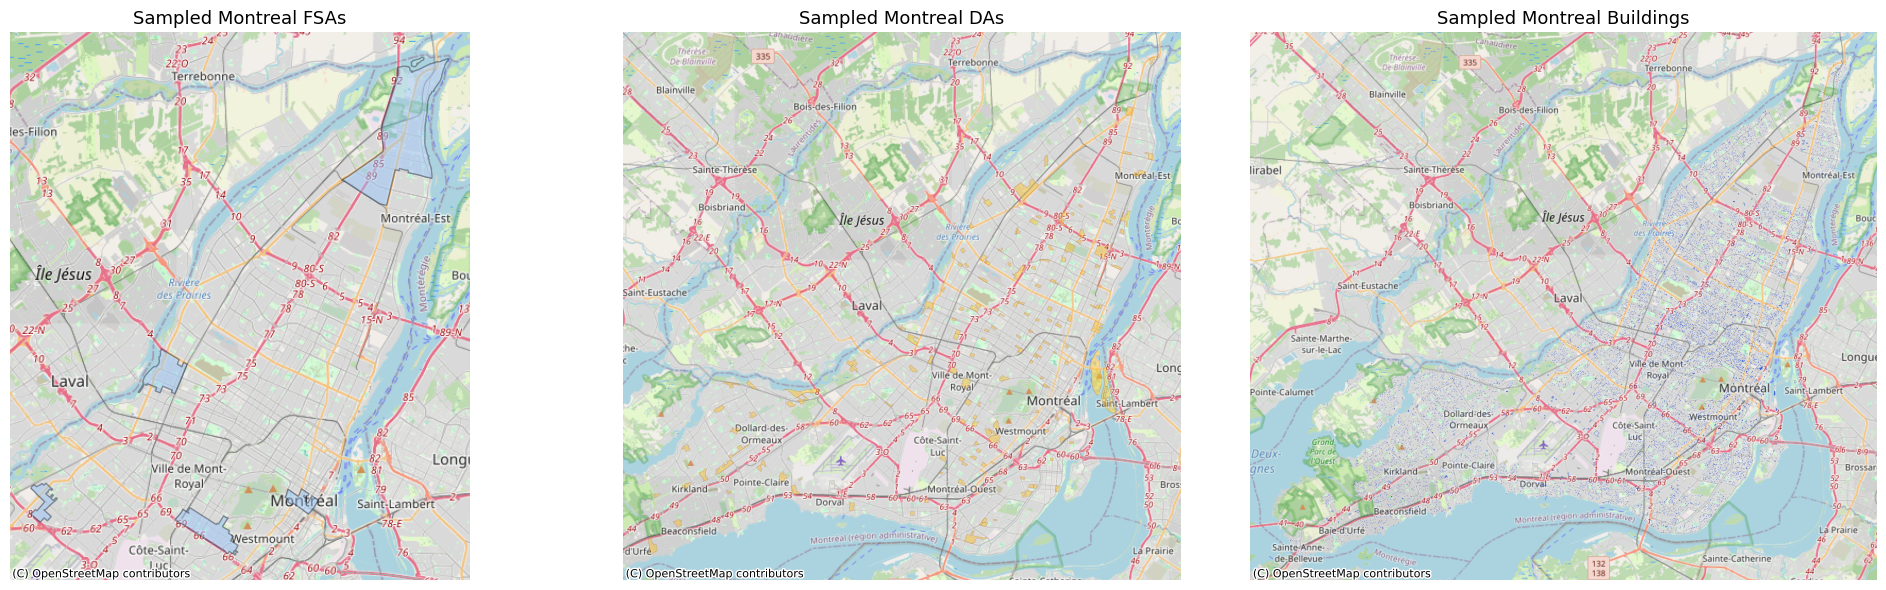

In [6]:
plot_spatial_samples_with_basemap(
    fsa_gdf=sampled_fsa_geo,
    da_gdf=sampled_da_geo,
    building_gdf=sampled_building_gdf,
    figsize=(20, 6),
    zoom=11,
)

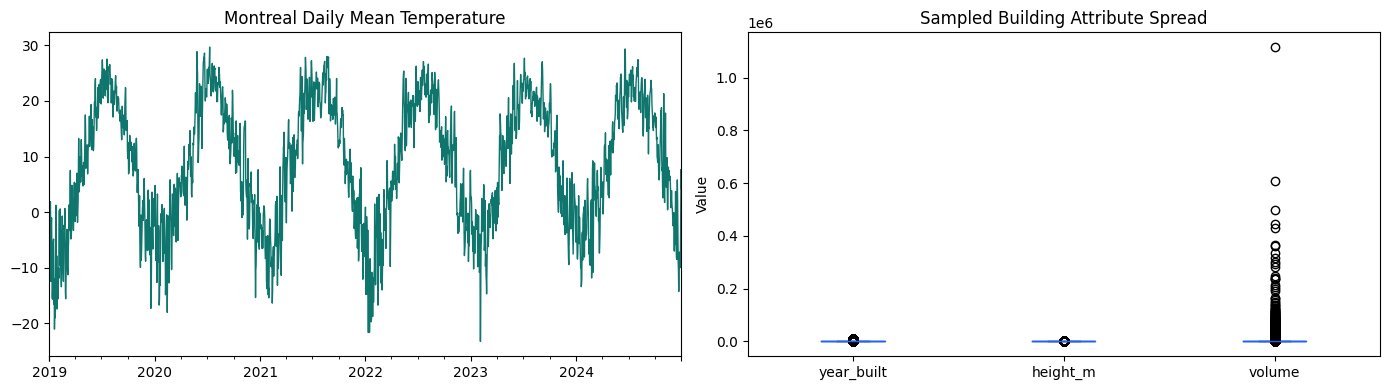

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weather_df.assign(date_time_local=pd.to_datetime(weather_df["date_time_local"]))     .set_index("date_time_local")["temperature"]     .resample("D").mean()     .plot(ax=axes[0], color="#0f766e", linewidth=1)
axes[0].set_title("Montreal Daily Mean Temperature")
axes[0].set_xlabel("")

metric_cols = ["year_built", "height_m", "volume"]
metric_df = sampled_building_df[metric_cols].apply(pd.to_numeric, errors="coerce")
metric_df.plot(kind="box", ax=axes[1], color="#2563eb")
axes[1].set_title("Sampled Building Attribute Spread")
axes[1].set_ylabel("Value")

plt.tight_layout()


## Build Montreal City Objects

- `montreal_full`: full FSA energy/census/weather context plus all Montreal DA geometry/census and sampled buildings
- `montreal_demo`: sampled FSA slice for faster analytics

In [8]:
cities_full = build_cities_from_data(
    elec_df=elec_df,
    city_geojsons={"montreal": fsa_geo},
    city_weather={"montreal": weather_df},
    census_df=fsa_census_df,
    city_da_geojsons={"montreal": da_geo},
    da_census_df=da_census_df,
    city_building_gdfs={"montreal": sampled_building_df},
    assign_building_units=False,
    show_progress=False,
)
montreal_full = cities_full["montreal"]

montreal_full.assign_building_units(overwrite=True)

cities_demo = build_cities_from_data(
    elec_df=sampled_elec_df,
    city_geojsons={"montreal": sampled_fsa_geo},
    city_weather={"montreal": weather_df},
    census_df=sampled_fsa_census_df,
    show_progress=False,
)
montreal_demo = cities_demo["montreal"]

print(f"Full Montreal city: {len(montreal_full.fsas)} FSAs, {len(montreal_full.das)} DAs, {len(montreal_full.buildings)} sampled buildings")
print(f"Demo Montreal city: {len(montreal_demo.fsas)} FSAs")

Full Montreal city: 94 FSAs, 3179 DAs, 16141 sampled buildings
Demo Montreal city: 5 FSAs


In [9]:
example_fsa = montreal_demo.get_fsa(montreal_demo.list_fsa_codes()[0])
example_building = montreal_full.get_building(montreal_full.list_building_codes()[0])

pd.DataFrame(
    {
        "entity": ["example_fsa", "example_building"],
        "code": [example_fsa.code, example_building.code],
        "fsa_code": [example_fsa.code, example_building.fsa_code],
        "building_type": [None, example_building.building_type],
        "year_built": [None, example_building.year_built],
        "height_m": [None, example_building.height_m],
    }
)

,entity,code,fsa_code,building_type,year_built,height_m
0,example_fsa,H1A,H1A,None,NaN,NaN
1,example_building,01000012,H2Y,Logement,1875.0,33.0


## Run Package Capabilities on the Sampled FSA Slice

In [10]:
normalized = example_fsa.normalize_for_weather(montreal_demo.weather)
per_capita = example_fsa.per_capita_consumption()
prism_summary = example_fsa.apply_heating_prism(montreal_demo.weather)
short_term_summary = example_fsa.short_term_metrics(show_progress=False)

print(f"Normalized points: {len(normalized)}")
print(f"Per-capita mean: {float(per_capita.mean()):.6f}")
print(f"Heating slope: {prism_summary['heating_slope_per_hdd']:.4f}")
print(f"Short-term rows: {len(short_term_summary)}")

Normalized points: 140256
Per-capita mean: 0.400757
Heating slope: 154.0738
Short-term rows: 1461


In [11]:
prism_table = montreal_demo.compute_prism_table(show_progress=False)
short_term_table = montreal_demo.compute_short_term_table(show_progress=False)

display(prism_table.head())
display(short_term_table.head())

,model,modele_ini,n_points,r2,cvrmse,sse,segment_counts,x0,x1,x2,...,k0,k1,k2,mean_load,mean_temp,all_candidates,heating_change_point_temp_c,baseload_intercept,heating_slope_per_hdd,cooling_slope_per_cdd
fsa,,,,,,,,,,,,,,,,,,,,,
H4S,3sg,15,140256,0.347443,0.197651,2229.314663,"{'left': 73637, 'middle': 21750, 'right': 44869}",-0.0523,10.0204,16.0022,...,-0.0072,-0.0101,0.0268,0.637869,8.379377,"{'2ch': {'p': [-0.0523, 3.8723, 17.4314, 0.639...",10.0204,0.5297,0.0101,0.0268
H3A,3sg,13,140256,0.486908,0.117227,1021.326902,"{'left': 68306, 'middle': 26709, 'right': 45241}",-10.6638,8.4495,15.9278,...,-0.0042,-0.0094,0.0239,0.727946,8.379377,"{'2ch': {'p': [-10.6638, 2.0806, 17.482, 0.805...",8.4495,0.6361,0.0094,0.0239
H1A,3sg,15,140256,0.526389,0.185548,775.513488,"{'left': 73309, 'middle': 22626, 'right': 44321}",0.0000,9.9132,16.1596,...,-0.0067,-0.0082,0.0237,0.400757,8.379377,"{'2ch': {'p': [0.0, 2.976, 17.7433, 0.3968, 0....",9.9132,0.3111,0.0082,0.0237
H2C,3sg,14,140256,0.470400,0.198725,819.728693,"{'left': 78727, 'middle': 19298, 'right': 42231}",-7.1205,11.4979,16.6583,...,-0.0010,-0.0069,0.0235,0.384703,8.379377,"{'2ch': {'p': [-7.1205, 5.1477, 17.8253, 0.442...",11.4979,0.3008,0.0069,0.0235
H3W,3sg,14,140256,0.448156,0.185594,348.914575,"{'left': 80765, 'middle': 18984, 'right': 40507}",-6.9328,12.0579,17.0643,...,0.0010,-0.0041,0.0154,0.268745,8.379377,"{'2ch': {'p': [-6.9328, 6.1752, 17.8728, 0.307...",12.0579,0.2170,0.0041,0.0154


,peak_load,p90_top10_mean,am_pm_peak_ratio,ramp_up_rate,dtw_cluster_label
fsa,,,,,
H1A,0.521219,0.510542,0.868295,0.021648,NaN
H2C,0.497993,0.487201,0.905064,0.023820,NaN
H3A,0.823838,0.813303,0.945114,0.032765,NaN
H3W,0.340485,0.334574,0.876885,0.012956,NaN
H4S,0.847843,0.817946,0.882534,0.048784,NaN


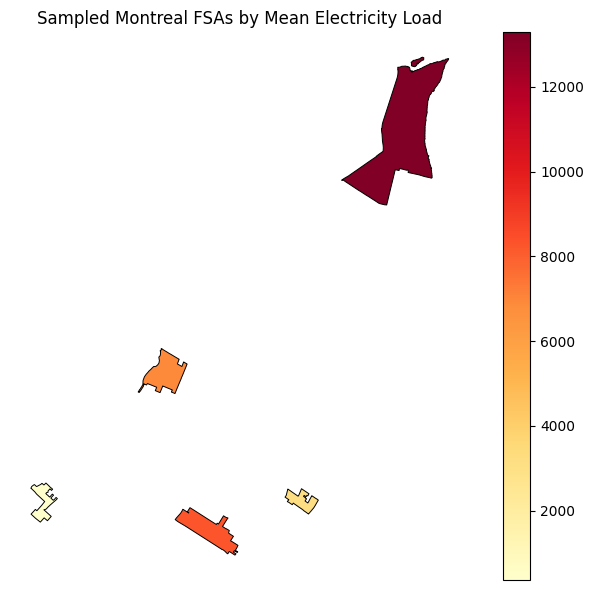

In [12]:
mean_load = sampled_elec_df.mean().rename("mean_load").reset_index().rename(columns={"index": "FSA"})
plot_gdf = sampled_fsa_geo.merge(mean_load, on="FSA", how="left")

fig, ax = plt.subplots(figsize=(7, 6))
plot_gdf.plot(column="mean_load", cmap="YlOrRd", legend=True, edgecolor="black", linewidth=0.7, ax=ax)
ax.set_title("Sampled Montreal FSAs by Mean Electricity Load")
ax.set_axis_off()
plt.tight_layout()

## Notes

- FSA analytics are the main energy-analysis path right now.
- DA geometry and census are available in the local data root, but DA electricity is not yet part of this notebook workflow.
- Buildings are included here as a sampled context layer and can already carry package methods if building-level energy is added later.